In [1]:
#Importing Libraries
import numpy as np
import pandas as pd 
import geopandas as gpd 

import numpyro
numpyro.set_host_device_count(4)
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive
from numpyro.diagnostics import hpdi

import jax
import jax.numpy as jnp

# check number of devices available
num_device = jax.local_device_count()
print("Number of available devices: ", num_device)
numpyro.set_host_device_count(4)

import arviz as az

import matplotlib.pyplot as plt

/Users/alydiaowens/uk-lung-model/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of available devices:  4


In [2]:
#loading mortality data 
data = pd.read_csv("/Users/alydiaowens/uk-lung-model/1376830934927918.csv", skiprows = 8) #skipping metadata
data = data.rename(columns = {"mnemonic": "LAD_code", "A00-R99,U00-Y89 All causes, all ages": "All deaths", "C33-C34 Malignant neoplasm of trachea, bronchus and lung": "Lung Cancer Deaths"})
data.head(3)

,local authority: district / unitary (as of April 2023),LAD_code,All deaths,Lung Cancer Deaths
0,Hartlepool,E06000001,1114,75
1,Middlesbrough,E06000002,1525,94
2,Redcar and Cleveland,E06000003,1797,118


In [3]:
#loading population estimates 
pop = pd.read_csv("/Users/alydiaowens/uk-lung-model/1380710199350457.csv", skiprows = 6) #skipping metadata
pop = pop.rename(columns = {"mnemonic": "LAD_code", "2023": "population"})
pop.head(3)

,local authority: district / unitary (as of April 2023),LAD_code,population
0,Hartlepool,E06000001,95366
1,Middlesbrough,E06000002,152650
2,Redcar and Cleveland,E06000003,137938


In [4]:
#loading geoportal data
gdf = gpd.read_file("/Users/alydiaowens/uk-lung-model/Local_Authority_Districts_December_2023_Boundaries_UK_BFC_9042356933902664268/LAD_DEC_2023_UK_BFC.shp")
gdf = gdf[['LAD23CD', 'geometry']].rename(columns = {'LAD23CD': "LAD_code"})
gdf.head(3)

,LAD_code,geometry
0,E06000001,"MULTIPOLYGON (((450154.599 525938.201, 450140...."
1,E06000002,"MULTIPOLYGON (((446854.7 517192.7, 446854.281 ..."
2,E06000003,"MULTIPOLYGON (((451747.397 520561.1, 451792.20..."


In [5]:
#merging death, population and geoportal data 

#merging death and population data
deathandpop = data.merge(pop, on="LAD_code")

#renaming name column 
deathandpop = deathandpop.rename(
    columns={"local authority: district / unitary (as of April 2023)_x": "LAD_name"}
)

#selecting columns
deathandpop = deathandpop[["LAD_name", "LAD_code", "Lung Cancer Deaths", "population"]]

#merging geoportal to deathandpop dataset
dataset = gdf.merge(deathandpop, on="LAD_code", how="left")

#converting population to float 
dataset["population"] = dataset["population"].astype(float)

#show dataframe
dataset.head(3)


,LAD_code,geometry,LAD_name,Lung Cancer Deaths,population
0,E06000001,"MULTIPOLYGON (((450154.599 525938.201, 450140....",Hartlepool,75.0,95366.0
1,E06000002,"MULTIPOLYGON (((446854.7 517192.7, 446854.281 ...",Middlesbrough,94.0,152650.0
2,E06000003,"MULTIPOLYGON (((451747.397 520561.1, 451792.20...",Redcar and Cleveland,118.0,137938.0


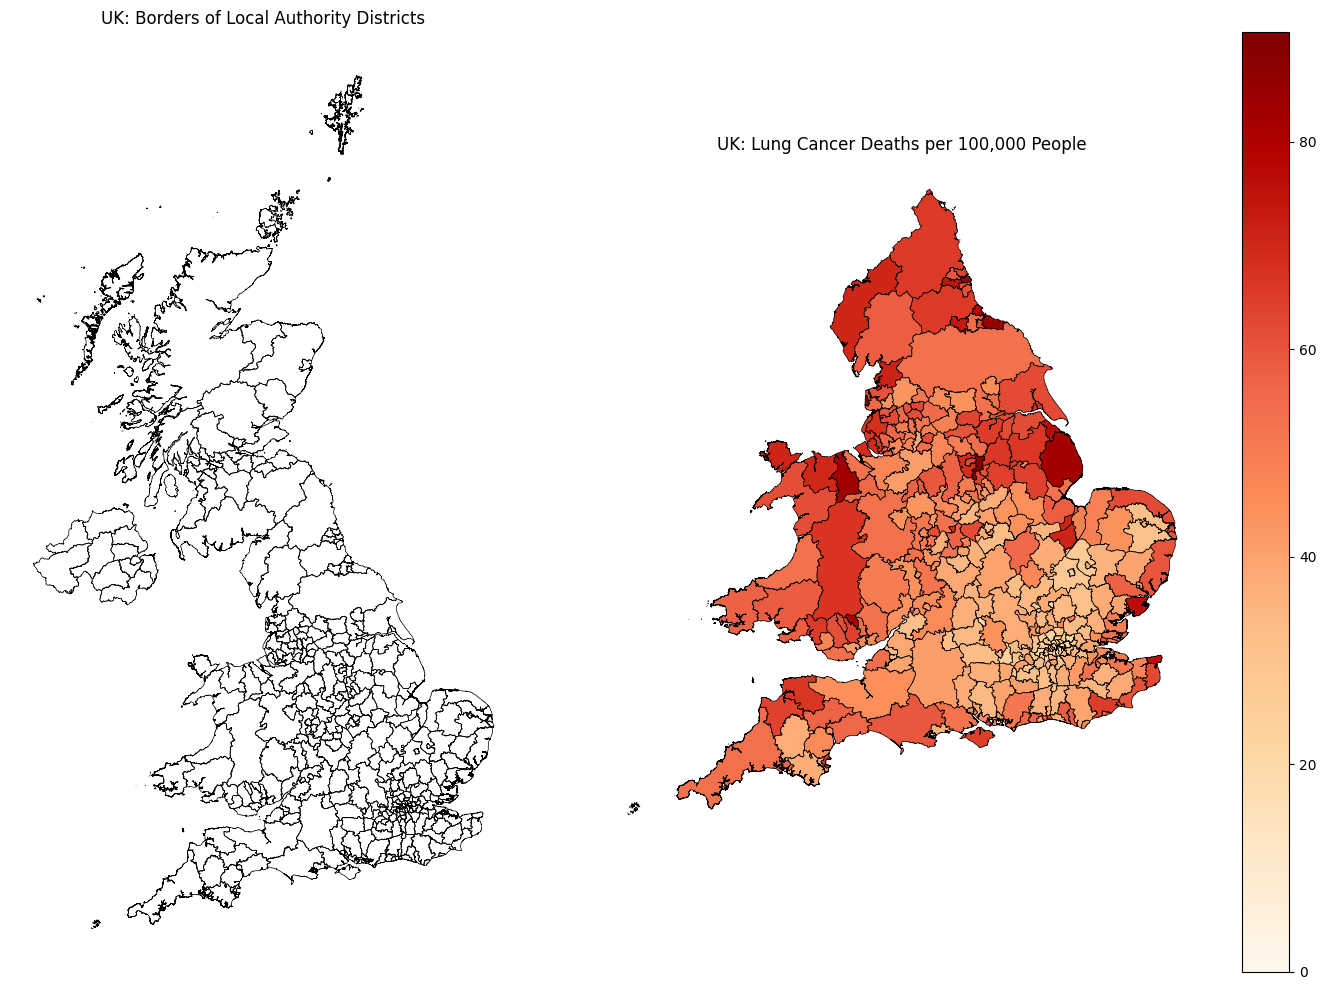

In [6]:
#plotting lung cancer mortality rates in UK 
import matplotlib.pyplot as plt

# Compute lung cancer mortality rate
dataset["lung_cancer_rate"] = (
    dataset["Lung Cancer Deaths"] / dataset["population"] * 100000
)

# Create side-by-side plots
fig, ax = plt.subplots(1, 2, figsize=(15, 10))

#Plot LAD boundaries only 
boundary_gdf = dataset.boundary
boundary_gdf.plot(ax=ax[0], color='black', lw=0.5)
ax[0].set_title('UK: Borders of Local Authority Districts')
ax[0].axis('off')

# 2. Plot lung cancer mortality rate
dataset.plot(
    column='lung_cancer_rate',
    ax=ax[1],
    cmap='OrRd',
    legend=True,
    edgecolor='black',
    linewidth=0.5
)
ax[1].set_title('UK: Lung Cancer Deaths per 100,000 People')
ax[1].axis('off')

plt.tight_layout()
plt.show()


In [7]:
# using normal likelihood because lung_cancer_rate is continuous 
#modified from numpyro textbook code (found here): https://elizavetasemenova.github.io/prob-epi/20_areal_data.html

def car_model(y,A): 
  ### Coding CAR function for any spatial data for reuse ###
  n = A.shape[0]
  d = jnp.sum(A, axis =1)
  D = jnp.diag(d)

  b0 = numpyro.sample('b0', dist.Normal(0,1))
  tau = numpyro.sample('tau', dist.Gamma(3,2))
  alpha = numpyro.sample('alpha', dist.Uniform(0.01,0.95))

  Q_std = D - alpha * A
  Q_std = Q_std + 1e-5 * jnp.eye(n) #ensuring positive definite matrix
  car_std = numpyro.sample('car_std', dist.MultivariateNormal(loc = jnp.zeros(n), precision_matrix = Q_std))
  sigma = numpyro.deterministic('sigma', 1./jnp.sqrt(tau))
  car = numpyro.deterministic('car', sigma *car_std)

  mu = b0 + car 
  numpyro.sample("obs", dist.Normal(loc = mu, scale = 0.1), obs = y)

In [8]:
# looking for null lung cancer rates which break MCMC model 
#assert not np.any(np.isnan(y))
#assert not np.any(np.isinf(y))

#removing nulls
dataset = dataset[dataset["lung_cancer_rate"].notna() & np.isfinite(dataset["lung_cancer_rate"])]

#dataset sorting by LAD code
dataset = dataset.sort_values("LAD_code") # sorting to match gdf 
gdf = gdf.sort_values("LAD_code") #sorting district codes 

gdf = gdf.loc[dataset.index]  

#ensuring indices match 
dataset = dataset.reset_index(drop=True)
gdf = gdf.reset_index(drop=True)

In [9]:
#defining y and A for this example
y = jnp.array(dataset["lung_cancer_rate"].values)

#calculating A 
from libpysal.weights import Queen 




## generating spatial weights 
w = Queen.from_dataframe(gdf)

##converting to adjacency matrix (A) 
A = w.full()[0] #shape 
A = jnp.array(A)


/Users/alydiaowens/uk-lung-model/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/var/folders/rh/dyt6bhv52qbdpcw_tc4qt_s00000gn/T/ipykernel_16544/2727903502.py:11: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
/Users/alydiaowens/uk-lung-model/venv/lib/python3.9/site-packages/libpysal/weights/weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
 There are 3 islands with ids: 43, 49, 296.
  warnings.warn(message)


In [ ]:
# Run MCMC to infer the parameters
import jax
print("Devices:", jax.local_device_count())
nuts_kernel = NUTS(car_model)
mcmc = MCMC(nuts_kernel, num_samples=100, num_warmup=100, chain_method = "parallel", num_chains = 4, progress_bar=True)
print("Chains:", mcmc.num_chains)
mcmc.run(rng_key=jax.random.PRNGKey(0), y=y, A=A)

# Extract posterior samples
samples = mcmc.get_samples()

mcmc.print_summary()

Devices: 4
Chains: 4


Compiling.. :   0%|          | 0/200 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/200 [00:02<?, ?it/s]





Running chain 0:   5%|▌         | 10/200 [00:03<00:22,  8.37it/s]



Running chain 0:  10%|█         | 20/200 [00:12<01:45,  1.70it/s]




Running chain 0:  15%|█▌        | 30/200 [00:30<03:12,  1.13s/it]


Running chain 0:  20%|██        | 40/200 [00:42<03:08,  1.18s/it]

Running chain 0:  25%|██▌       | 50/200 [00:56<03:05,  1.24s/it]


Running chain 0:  40%|████      | 80/200 [01:11<01:25,  1.40it/s]

Running chain 0:  60%|██████    | 120/200 [01:43<01:03,  1.26it/s]

Running chain 0:  90%|█████████ | 180/200 [04:35<01:20,  4.04s/it]


